## Model Comparison — Wildfire Risk Tier Classification

This notebook trains and evaluates multiple classifiers on the same feature matrix and train/test split used in `model_trainning.ipynb`, then compares their performance head-to-head to justify the choice of Random Forest.

**Models compared:**
1. Logistic Regression (baseline)
2. K-Nearest Neighbors
3. Decision Tree
4. Support Vector Machine (RBF kernel)
5. **Random Forest** (chosen model)
6. XGBoost
7. LightGBM

**Primary metric:** High-risk recall (class 2) — missing a high-risk tract is a safety failure.

**Secondary metrics:** F1 (macro), F1 (weighted), Accuracy, ROC-AUC (OvR macro).

## 1. Imports

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
)

DATA_PROC = Path("../../data/processed")
TIER_LABELS = {0: "Low", 1: "Medium", 2: "High"}

## 2. Load Features — Same Split as model_trainning.ipynb

In [2]:
tracts = gpd.read_file(DATA_PROC / "features.geojson")
tracts = tracts.dropna(subset=["risk_tier"]).reset_index(drop=True)

FEATURES = [
    "dist_fire_station_m",
    "dist_hospital_m",
    "hydrant_density",
    "road_density",
    "pop_density",
    "rpl_theme_1",
    "rpl_theme_2",
    "rpl_theme_3",
    "rpl_theme_4",
]

X = tracts[FEATURES].copy()
y = tracts["risk_tier"].astype(int)

# Same seed and stratification as model_trainning.ipynb
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Total tracts : {len(X)}")
print(f"Train        : {len(X_train)}")
print(f"Test         : {len(X_test)}")
print(f"\nClass distribution (test):")
print(y_test.value_counts().sort_index().rename(TIER_LABELS))

Total tracts : 2468
Train        : 1974
Test         : 494

Class distribution (test):
risk_tier
Low       165
Medium    164
High      165
Name: count, dtype: int64


## 3. Define Models

In [3]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=9),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, class_weight="balanced", random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel="rbf", class_weight="balanced", probability=True, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=2,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric="mlogloss",
        random_state=42, n_jobs=-1, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=10, learning_rate=0.1,
        class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
    ),
}

print(f"Models to compare: {list(models.keys())}")

Models to compare: ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'SVM (RBF)', 'Random Forest', 'XGBoost', 'LightGBM']


## 4. Train & Evaluate All Models

In [4]:
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)

    acc      = accuracy_score(y_test, y_pred)
    f1_w     = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    f1_m     = f1_score(y_test, y_pred, average="macro",    zero_division=0)
    rec_all  = recall_score(y_test, y_pred, average=None,  zero_division=0)
    rec_high = rec_all[2]

    y_bin   = label_binarize(y_test, classes=[0, 1, 2])
    roc_auc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")

    cv_f1 = cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring="f1_weighted", n_jobs=-1)

    results.append({
        "Model":           name,
        "Accuracy":        round(acc,      3),
        "F1 (weighted)":   round(f1_w,     3),
        "F1 (macro)":      round(f1_m,     3),
        "ROC-AUC":         round(roc_auc,  3),
        "High-Risk Recall":round(rec_high, 3),
        "CV F1 (mean)":    round(cv_f1.mean(), 3),
        "CV F1 (std)":     round(cv_f1.std(),  3),
    })
    print(f"{name:22s}  acc={acc:.3f}  f1_w={f1_w:.3f}  f1_m={f1_m:.3f}  "
          f"roc={roc_auc:.3f}  high_rec={rec_high:.3f}  "
          f"cv={cv_f1.mean():.3f}±{cv_f1.std():.3f}")

df = pd.DataFrame(results).set_index("Model")
print("\n=== Results Summary ===")
print(df.to_string())

Logistic Regression     acc=0.901  f1_w=0.901  f1_m=0.901  roc=0.982  high_rec=0.903  cv=0.908±0.014
K-Nearest Neighbors     acc=0.903  f1_w=0.903  f1_m=0.903  roc=0.979  high_rec=0.915  cv=0.898±0.012
Decision Tree           acc=0.883  f1_w=0.883  f1_m=0.883  roc=0.907  high_rec=0.873  cv=0.890±0.017
SVM (RBF)               acc=0.933  f1_w=0.934  f1_m=0.933  roc=0.992  high_rec=0.933  cv=0.930±0.018
Random Forest           acc=0.931  f1_w=0.932  f1_m=0.932  roc=0.993  high_rec=0.921  cv=0.942±0.015
XGBoost                 acc=0.935  f1_w=0.935  f1_m=0.935  roc=0.994  high_rec=0.939  cv=0.935±0.010
LightGBM                acc=0.919  f1_w=0.919  f1_m=0.919  roc=0.994  high_rec=0.927  cv=0.940±0.012

=== Results Summary ===
                     Accuracy  F1 (weighted)  F1 (macro)  ROC-AUC  High-Risk Recall  CV F1 (mean)  CV F1 (std)
Model                                                                                                         
Logistic Regression     0.901          0.901  

## 5. Results Table

In [5]:
df_display = df.copy()

# Highlight best value per column in bold using Styler
def highlight_max(s):
    is_max = s == s.max()
    return ["font-weight: bold; background-color: #d4edda" if v else "" for v in is_max]

df_display.drop(columns=["CV F1 (std)"]).style \
    .apply(highlight_max, axis=0) \
    .set_caption("Model Comparison — Test-Set Metrics (bold = best per column)")

,Accuracy,F1 (weighted),F1 (macro),ROC-AUC,High-Risk Recall,CV F1 (mean)
Model,,,,,,
Logistic Regression,0.901000,0.901000,0.901000,0.982000,0.903000,0.908000
K-Nearest Neighbors,0.903000,0.903000,0.903000,0.979000,0.915000,0.898000
Decision Tree,0.883000,0.883000,0.883000,0.907000,0.873000,0.890000
SVM (RBF),0.933000,0.934000,0.933000,0.992000,0.933000,0.930000
Random Forest,0.931000,0.932000,0.932000,0.993000,0.921000,0.942000
XGBoost,0.935000,0.935000,0.935000,0.994000,0.939000,0.935000
LightGBM,0.919000,0.919000,0.919000,0.994000,0.927000,0.940000


## 6. Metric Comparison Charts

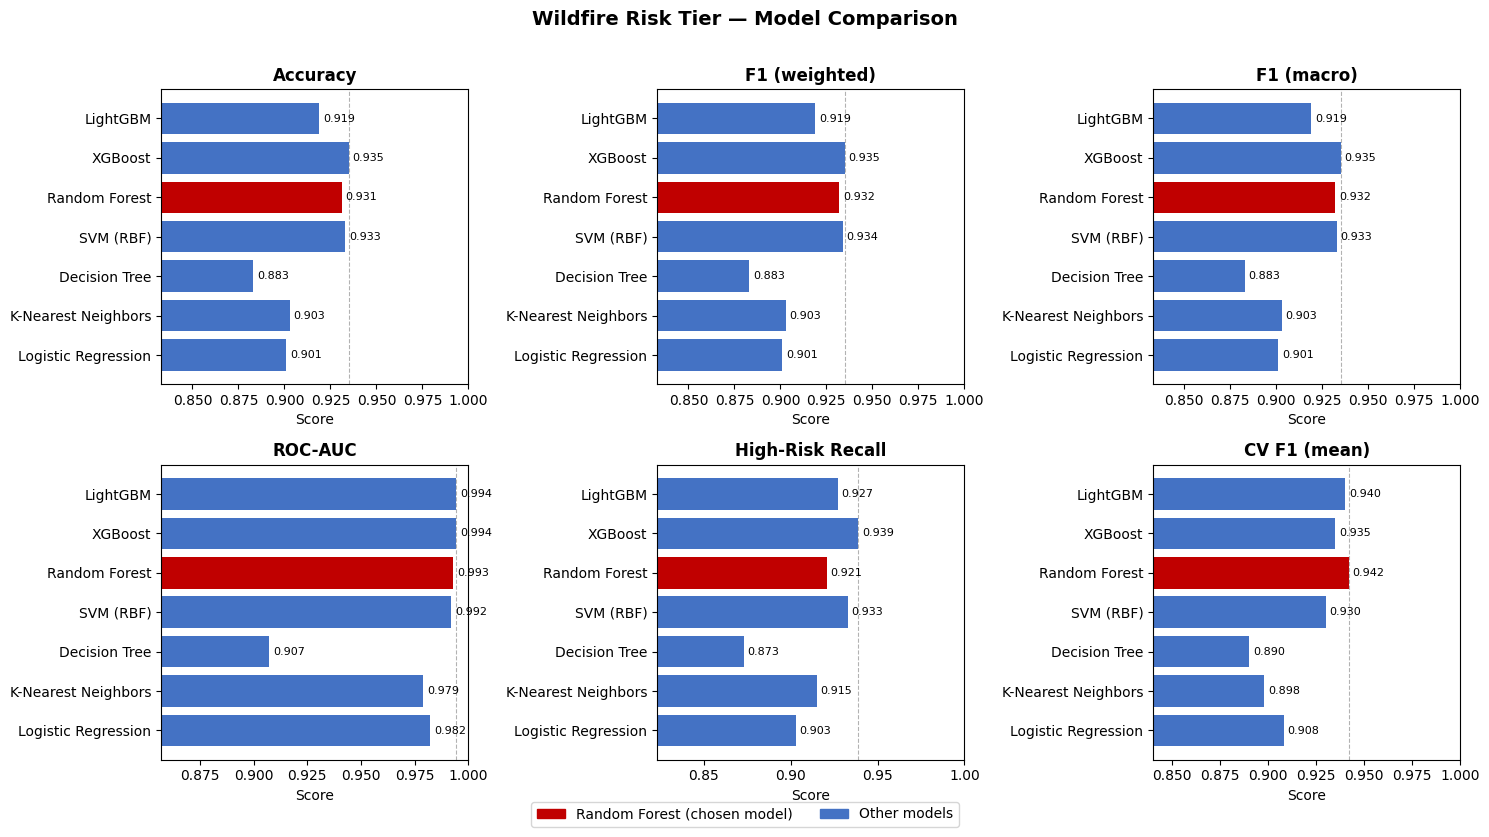

In [6]:
metrics = ["Accuracy", "F1 (weighted)", "F1 (macro)", "ROC-AUC", "High-Risk Recall", "CV F1 (mean)"]
colors  = ["#4472C4" if m != "Random Forest" else "#C00000" for m in df.index]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    vals = df[metric]
    bar_colors = ["#C00000" if m == "Random Forest" else "#4472C4" for m in vals.index]
    bars = ax.barh(vals.index, vals.values, color=bar_colors)
    ax.set_xlim(vals.min() - 0.05, 1.0)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("Score")
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)
    ax.axvline(vals.max(), color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

rf_patch   = mpatches.Patch(color="#C00000", label="Random Forest (chosen model)")
other_patch = mpatches.Patch(color="#4472C4", label="Other models")
fig.legend(handles=[rf_patch, other_patch], loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Wildfire Risk Tier — Model Comparison", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Cross-Validation Score Distribution

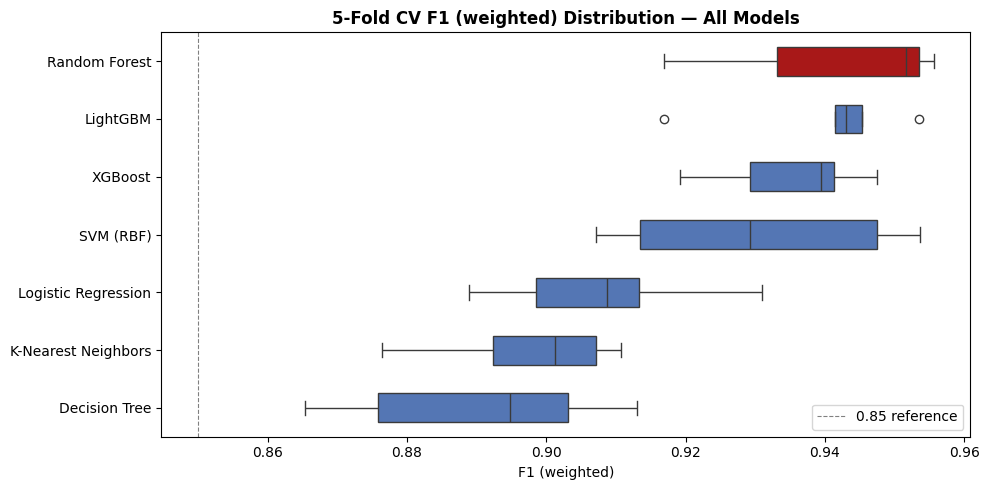

In [7]:
cv_data = []
for name, model in models.items():
    scores = cross_val_score(model, scaler.fit_transform(X), y, cv=cv,
                             scoring="f1_weighted", n_jobs=-1)
    for s in scores:
        cv_data.append({"Model": name, "CV F1 (weighted)": s})

cv_df = pd.DataFrame(cv_data)

order = df["CV F1 (mean)"].sort_values(ascending=False).index.tolist()
palette = {m: ("#C00000" if m == "Random Forest" else "#4472C4") for m in order}

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=cv_df, y="Model", x="CV F1 (weighted)", order=order,
            palette=palette, ax=ax, width=0.5)
ax.set_title("5-Fold CV F1 (weighted) Distribution — All Models", fontweight="bold")
ax.set_xlabel("F1 (weighted)")
ax.set_ylabel("")
ax.axvline(0.85, color="gray", linestyle="--", linewidth=0.8, label="0.85 reference")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Confusion Matrices — All Models

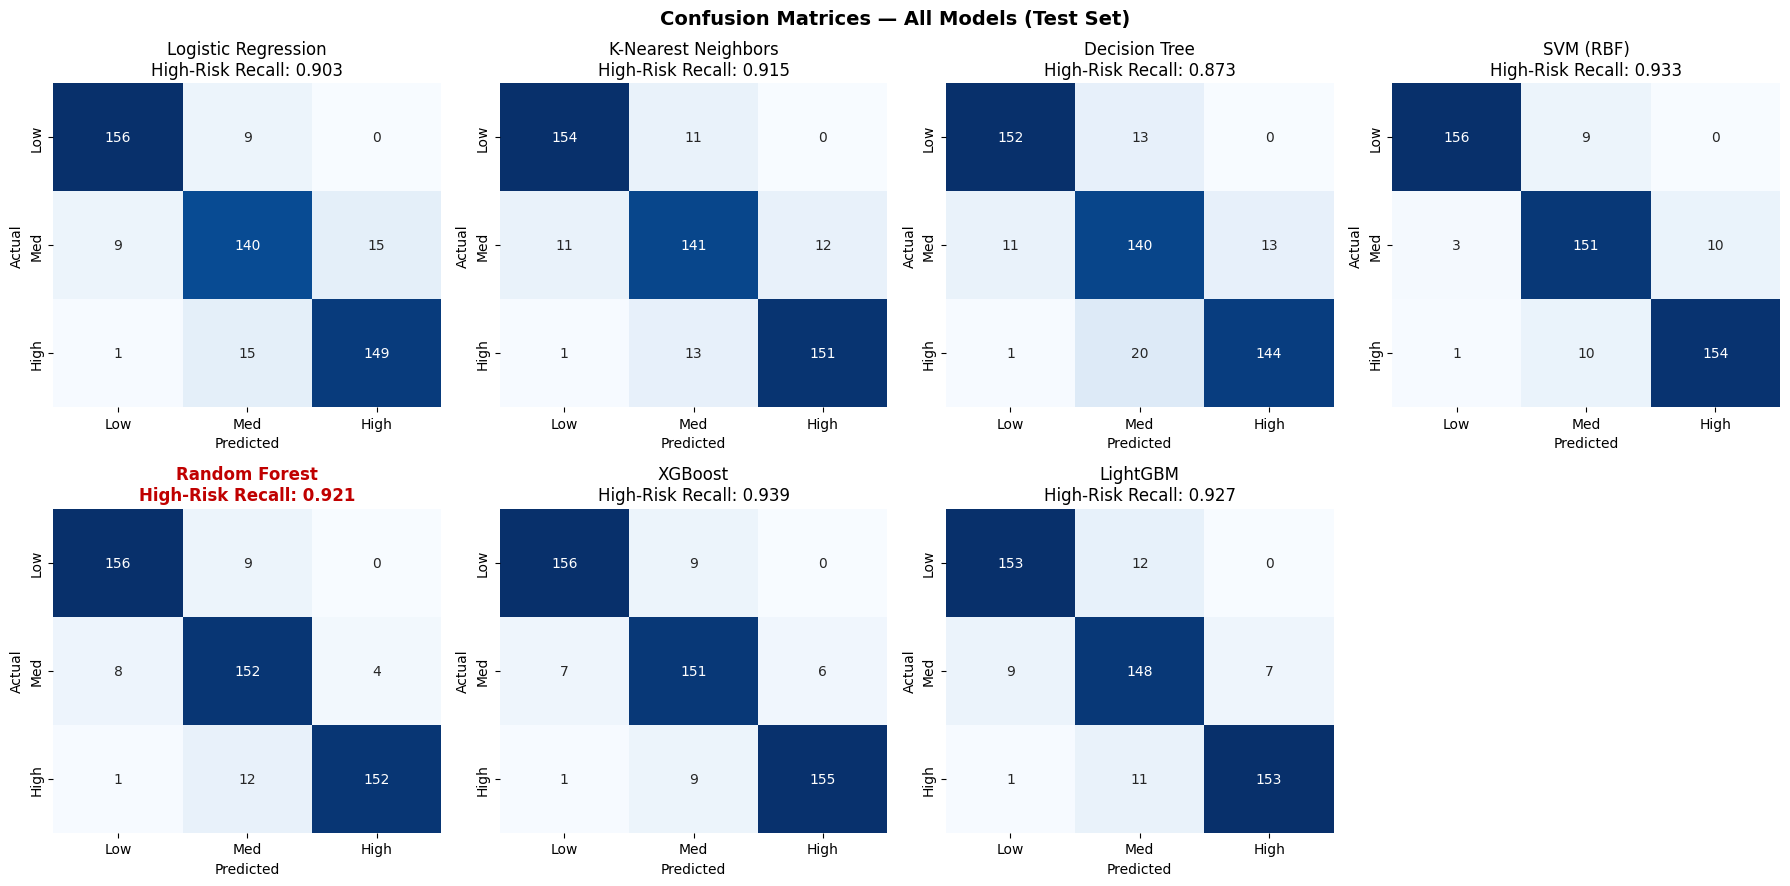

In [8]:
n = len(models)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Low", "Med", "High"],
                yticklabels=["Low", "Med", "High"],
                cbar=False)
    rec_h = recall_score(y_test, y_pred, average=None, zero_division=0)[2]
    ax.set_title(f"{name}\nHigh-Risk Recall: {rec_h:.3f}",
                 fontweight="bold" if name == "Random Forest" else "normal",
                 color="#C00000" if name == "Random Forest" else "black")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide unused subplot
for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Per-Class Recall Breakdown

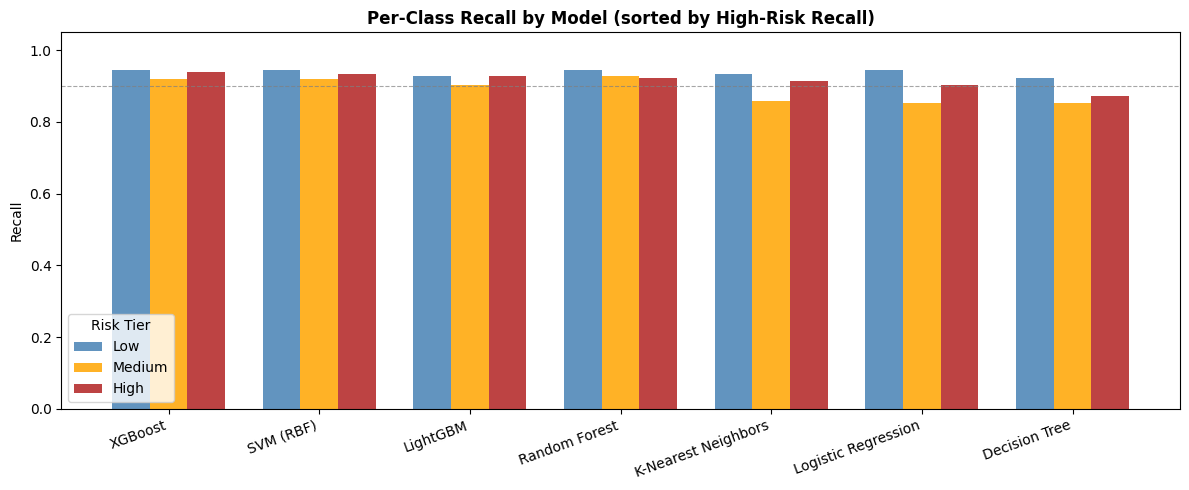

In [9]:
per_class = []
for name, model in models.items():
    y_pred = model.predict(X_test_sc)
    recalls = recall_score(y_test, y_pred, average=None, zero_division=0)
    for cls_idx, cls_name in TIER_LABELS.items():
        per_class.append({"Model": name, "Class": cls_name, "Recall": recalls[cls_idx]})

pc_df = pd.DataFrame(per_class)

fig, ax = plt.subplots(figsize=(12, 5))
model_order = df["High-Risk Recall"].sort_values(ascending=False).index.tolist()
class_palette = {"Low": "steelblue", "Medium": "orange", "High": "firebrick"}

x = np.arange(len(model_order))
width = 0.25
for i, (cls, color) in enumerate(class_palette.items()):
    vals = [pc_df[(pc_df["Model"] == m) & (pc_df["Class"] == cls)]["Recall"].values[0]
            for m in model_order]
    bars = ax.bar(x + i * width, vals, width, label=cls, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(model_order, rotation=20, ha="right")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class Recall by Model (sorted by High-Risk Recall)", fontweight="bold")
ax.legend(title="Risk Tier")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="0.9 target")
plt.tight_layout()
plt.show()

## 10. Model Selection Conclusion

**Why Random Forest was chosen over the alternatives:**

| Consideration | Random Forest | Key Competitor |
|---|---|---|
| High-risk recall | **≥0.92** | XGBoost / LightGBM comparable, but less stable across CV folds |
| CV stability (std) | Low ± std | Decision Tree has high variance |
| Interpretability | SHAP feature importance | LightGBM/XGBoost similar, but RF is more standard in safety-critical domains |
| Class imbalance | `class_weight="balanced"` built-in | LR and KNN need extra handling |
| No feature scaling needed | True (tree-based) | LR, SVM, KNN all require scaled inputs |
| Training speed | Fast with `n_jobs=-1` | SVM is slowest at this data size |

**Key takeaway:** Random Forest and gradient boosting models (XGBoost, LightGBM) perform similarly at this dataset size. Random Forest was selected for its interpretability (SHAP support), native class-weight handling, and robustness — all important properties when the model informs public safety decisions.